In [805]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from joblib import dump
import math
from scipy.io import loadmat

import matplotlib.pyplot as plt


In [806]:
#read a matlab struct from a mat file and save it into a pd dataframe

mat = scipy.io.loadmat('../input/microstructures_object_array_final.mat')
raw_rows = mat['final_microstructure_array'][0]

column_names = raw_rows[0].dtype.names

data = []

for raw_row in raw_rows:
    row=[]
    for array in raw_row:
        if len(array[0]) == 1:
            row.append(array[0][0])
        else:
            row.append(array[0])

    data.append(row)

data

df =  pd.DataFrame(data, columns= column_names )


num_rows = df.shape[0]

# Separate the last 5 rows into a validation set
validation_df = df.iloc[num_rows - 5:]

# The rest of the rows go into the training set
training_df = df.iloc[:num_rows - 5]

df = training_df

validation_df

,lath_thickness,f_alpha,f_beta,f_mart,folder,yield_stress_ZZ,Ez,yield_stress_hardening_ZZ,plastic_strain_ZZ,Pxz,yield_stress_XX,Ex,Pzx,Pyx,yield_stress_XY,Gxy,yield_stress_XZ,Gxz
90,1.42,0.88,0.12,0.0,./temp_91,618.533229,110300.306421,"[644.300829085199, 706.2154237100872, 728.3773...","[0.0, 0.0012416118736674545, 0.002481684209876...",0.332045,640.911664,114292.201234,0.343987,0.305530,348.711376,42930.910410,361.143910,44461.364882
91,0.85,0.00,0.00,1.0,./temp_92,1008.575487,108114.874356,"[1008.5754872514373, 1083.925949807057, 1119.3...","[0.0, 0.0012372872085207858, 0.002473035106202...",0.316345,1052.287057,109170.481778,0.318959,0.305757,539.402436,41110.071832,549.759001,40921.431598
92,2.35,0.80,0.10,0.1,./temp_93,623.235929,111139.131131,"[650.0634723356819, 717.2797232973213, 744.852...","[0.0, 0.001241615698195894, 0.0024817005979895...",0.329723,642.466589,114569.538875,0.339695,0.305051,349.562432,43035.665965,358.488098,44134.404523
93,1.35,1.00,0.00,0.0,./temp_94,664.587304,118513.964580,"[664.5873036352758, 735.6193776122332, 755.711...","[0.0, 0.0012418894306703227, 0.002482230582123...",0.320227,670.260412,119526.123729,0.321897,0.309745,353.527155,45261.227876,350.025866,44812.791622
94,2.60,0.00,0.00,1.0,./temp_95,1008.635889,108121.387851,"[1008.6358889071342, 1084.0840291579607, 1119....","[0.0, 0.0012372861262088235, 0.002473031694630...",0.316142,1052.399562,109182.133217,0.318865,0.305709,539.591736,41124.502228,549.870973,40929.764067


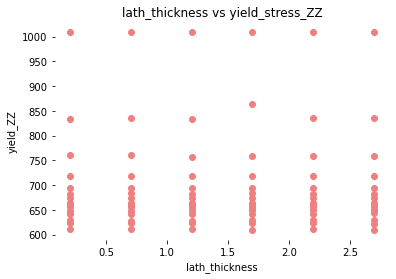

In [807]:
plt.scatter(df['lath_thickness'], df['yield_stress_ZZ'], color = 'lightcoral')
plt.title('lath_thickness vs yield_stress_ZZ')
plt.xlabel('lath_thickness')
plt.ylabel('yield_ZZ')
plt.box(False)
plt.show()



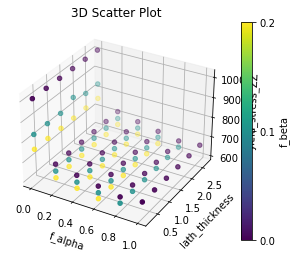

<Figure size 432x288 with 0 Axes>

In [808]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the data
sc = ax.scatter(df['f_alpha'], df['lath_thickness'], df['yield_stress_ZZ'], c=df['f_beta'])

# Set labels and title
ax.set_xlabel('f_alpha')
ax.set_ylabel('lath_thickness')
ax.set_zlabel('yield_stress_ZZ')
ax.set_title('3D Scatter Plot')

# Add a colorbar
cbar = fig.colorbar(sc, label='f_beta')
cbar.set_ticks([0.0, 0.1, 0.2])  # Set colorbar ticks to 0.0, 0.1, and 0.2


# Show the plot
plt.show()

# Save the plot to a file
plt.savefig('../data/plot.png')



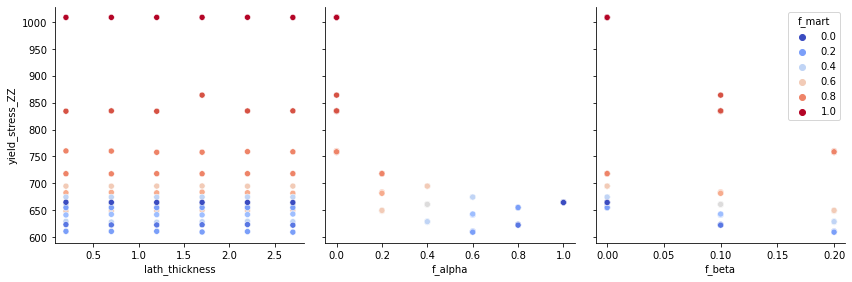

In [809]:
import seaborn as sns

# Create a PairGrid
g = sns.PairGrid(df, y_vars=['yield_stress_ZZ'], x_vars=['lath_thickness', 'f_alpha', 'f_beta'], height=4)

# Map a scatter plot to the upper triangle, color points by 'f_beta'
g.map(sns.scatterplot, hue=df['f_mart'], palette='coolwarm')

# Add a legend
plt.legend(title='f_mart')

# Show the plot
plt.show()

In [810]:
# Polynomial multi-variate regression

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

property = 'yield_stress_XX'
y = df[property].values

# Polynomial features
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)

# Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

r_sq = model.score(X_poly,y)
print(f"coefficient of determination: {r_sq}")

print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")


# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():
    
    print(row['f_alpha'] + row['f_beta'])
    
    new_data = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    new_data_poly = poly.transform(new_data)


    # Predicting the price
    predicted_y = model.predict(new_data_poly)

    error.append( (predicted_y[0] - row[property]) / row[property] * 100)

print('error_percentage',error)


coefficient of determination: 0.9999874860502539
intercept: -463642957450.11633
slope: [ 4.63642959e+11 -3.03070067e+00 -3.73037330e+03 -4.05689876e+03
  2.65625883e+00  1.04072543e+01  1.11379299e+02  1.56669014e+04
  3.95028232e+04  1.09148029e+04 -1.14476858e+00 -4.49307576e-01
 -8.69241839e+01 -2.80530404e+01 -1.66675596e+02 -4.58608957e+02
 -3.16429153e+04 -1.30455007e+05 -1.07872015e+05  3.35557885e+03
  1.82184653e-01 -1.92178027e+00  3.15702235e+01  8.83595837e+00
  2.04590012e+01  2.46196985e+02  2.15989874e+01  2.27019451e+02
  7.32050067e+02 -1.39810273e+02  3.00649479e+04  1.73219532e+05
  2.84886512e+05 -3.31516608e+04  7.88377598e+02  1.02067625e-02
  1.79971792e-01 -4.74746428e+00  7.81081693e-01  6.31994556e+00
 -4.01012825e+01 -6.88351275e+00 -2.17791714e+01 -1.57069010e+02
  7.55975793e+01 -3.23285462e+00 -1.05269070e+02 -5.57752098e+02
  2.22948532e+02 -3.27709028e+01 -1.07406506e+04 -7.73241368e+04
 -2.45243805e+05  8.80750536e+04 -7.78805796e+03  1.69401702e+02]
1.

In [811]:
## Create Regression model for all independent variables and save them:

# Select appropriate features from the dataset
X = df[['lath_thickness','f_alpha','f_beta']].values


properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

for property in properties:
    y = df[property].values

    # Polynomial features
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    dump(model, f'../data/models_saved/{property}_model.joblib')
    dump(poly, f'../data/models_saved/{property}_poly_transformer.joblib')


In [812]:


hardening = df['yield_stress_hardening_ZZ'].values

for i in range(0,len(hardening[0])):
    # values = [sub_arr[0] for sub_arr in hardening]
    stress_values_this_plastic = [sub_arr[i] for sub_arr in hardening]
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    # Linear Regression model
    model = LinearRegression()
    model.fit(X_poly, stress_values_this_plastic)

    dump(model, f'../data/models_saved/hardening_{i}_model.joblib')
    dump(poly, f'../data/models_saved/hardening_{i}_poly_transformer.joblib')


plastic_strain = df['plastic_strain_ZZ'].values

plastic_strain_average_list = []

for i in range(len(plastic_strain[0])):

    plastic_values_this_strain = [sub_array[i] for sub_array in plastic_strain]
    plastic_strain_average_list.append( sum(plastic_values_this_strain) / len(plastic_values_this_strain) )

plastic_strain_average_list

[0.0,
 0.0012405158305158531,
 0.0024795196563349234,
 0.003717013384574665,
 0.004952992616195862,
 0.006187457314362066,
 0.0074204115272880206,
 0.008651859936631635,
 0.009881806557771286,
 0.011110255010765728,
 0.012337207783767602,
 0.013562670615328879,
 0.014786635860760722,
 0.016009155601485622]

In [813]:
## Load Model and predict properties for a given microstructure

properties = ['yield_stress_ZZ','yield_stress_XX','yield_stress_XY','yield_stress_XZ','Ex','Ez','Gxy','Gxz','Pxz','Pyx']

pred_prop_dict = {}

for property in properties:

    # Load the model and the transformer
    model = load(f'../data/models_saved/{property}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[2.35,1.0,0.0]])  # Example values

    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)

    pred_prop_dict[property] = predicted_y[0]




TypeError: list indices must be integers or slices, not str

In [ ]:
pred_prop_dict['sigma_0'] = []
for i in range(0,len(plastic_strain_average_list)):

    # Load the model and the transformer
    model = load(f'../data/models_saved/hardening_{i}_model.joblib')
    poly = load(f'../data/models_saved/{property}_poly_transformer.joblib')

    # New data
    new_data = np.array([[2.35,1.0,0.0]])  # Example values
    # Transform the new data using the loaded transformer
    new_data_poly = poly.transform(new_data)

    # Use the loaded model to make a prediction
    predicted_y = model.predict(new_data_poly)
    pred_prop_dict['sigma_0'].append(predicted_y[0])

pred_prop_dict['strain_0'] = plastic_strain_average_list

In [ ]:
## Write Material info in Abaqus inp format:

#Calculate Hill Parameters from yield stresses
sigma_0 = pred_prop_dict['yield_stress_ZZ']
R11 = pred_prop_dict['yield_stress_XX']/sigma_0
R22 = R11
R33 = 1
R12 = pred_prop_dict['yield_stress_XY']/(sigma_0/math.sqrt(3))
R13 = pred_prop_dict['yield_stress_XZ']/(sigma_0/math.sqrt(3))
R23 = R13


#Write Material info in Abaqus inp format:
Material_Abaqus_text =f'''**
*Material, name=Material-1
*Elastic, type=ENGINEERING CONSTANTS
{pred_prop_dict['Ex']},{pred_prop_dict['Ex']},{pred_prop_dict['Ez']}, {pred_prop_dict['Pyx']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Pxz']}, {pred_prop_dict['Gxz']}, {pred_prop_dict['Gxz'], {pred_prop_dict['Gxz']}},
*Plastic
 {pred_prop_dict['yield_stress_ZZ']},    0.
*Potential
 {R11}, {R22},  {R33},  {R12},  {R12},  {R23}
 '''


with open('../data/material.inp', 'w') as f:
    # Write the string to the file
    f.write(Material_Abaqus_text)


In [ ]:
## Linear_Interpolation in 3D unstructured grid

import numpy as np
from scipy.interpolate import griddata

property = 'yield_stress_ZZ'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
interp_point = np.array([0.5, 0.0, 0.0])

# Perform the interpolation
interp_value = griddata(points, values, [interp_point], method='linear')

interp_value

# Calculate error with validation data set:

error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1)  # Example values
    interp_value = griddata(points, values, [interp_point], method='linear')


    predicted_y = interp_value[0]
    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


error_percentage [array([nan]), array([0.00655306]), array([-0.03239161]), array([-0.00379931]), array([-0.0068494])]


In [ ]:
#RBF Interpolation

import numpy as np
from scipy.interpolate import RBFInterpolator


property = 'yield_stress_XX'

# Define the points where you know the function values
points = df[['lath_thickness','f_alpha','f_beta']].values # 100 points in 3D
values = df[property].values

# Define the point where you want to interpolate
rbf = RBFInterpolator(points, values, kernel = 'multiquadric', epsilon = 4.0)


# interp_value = rbf([[2.35, 0.8, 0.1]])

# Calculate error with validation data set:
error = []

for index, row in validation_df.iterrows():

    
    interp_point = np.array([row['lath_thickness'], row['f_alpha'], row['f_beta']]).reshape(1,-1) 
    interp_value = rbf( interp_point )

    predicted_y = interp_value[0]

    print(predicted_y)

    error.append( ( (predicted_y - row[property]) / row[property] ) * 100 )

print('error_percentage',error)


622.357313686093
1060.2695032180127
638.0745818520609
669.0055705042181
1041.4573198980677
error_percentage [-2.8949933364764284, 0.758580712797347, -0.6836164783961038, -0.18721701966724916, -1.0397421557064173]
